# 

STUDENT: JOEL S. MOLLEL

NUMBER: C00313599

ALGORITHM: Naive Bayesian

STAGE 1: Making the given notebook work

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-whitegrid') - This plotting style is no longer available in Matplotlib!

I had to use print(plt.style.available) - to see all available plotting options. I picked 'seaborn-v0_8-whitegrid' as my style which is similar to the original one. You can change style by choosing one from the output of the line of code below.

In [2]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


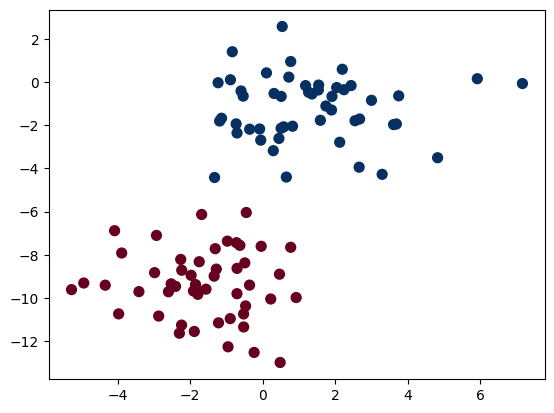

In [3]:
from sklearn.datasets import make_blobs
X, y = make_blobs(100, 2, centers=2, random_state=2, cluster_std=1.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='RdBu');

STAGE 2: Adjustment of parameters and see how they affect the classification

A: Clusters begin to overlap when their cluster centers are moved closer to each other. 

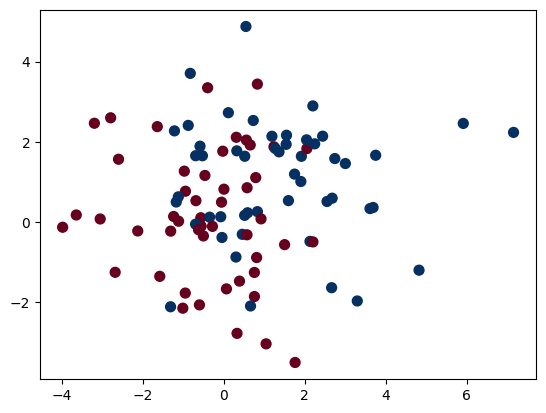

In [4]:
X, y = make_blobs(100, 2, centers=[(0, 0), (1, 1)], random_state=2, cluster_std=1.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='RdBu')
plt.show()

B: The more you raise the standard deviation, the clusters tend to overlap, the higher the degree of intersection between them.

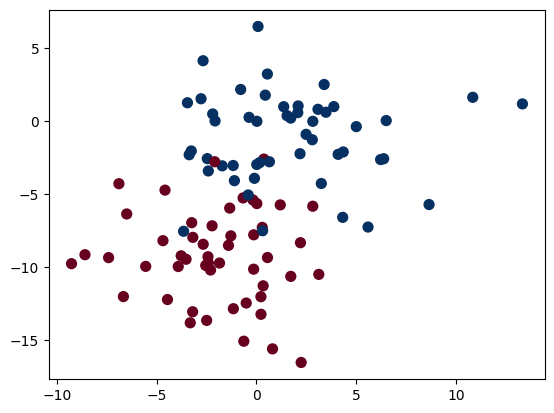

In [5]:
X, y = make_blobs(100, 2, centers=2, random_state=2, cluster_std=3)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='RdBu')
plt.show()

C: The more you reduce the standard deviation, the clusters tend to spread out, reducing the degree of intersection between them.

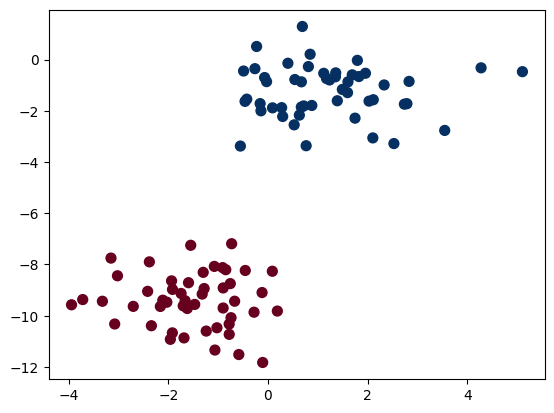

In [6]:
X, y = make_blobs(100, 2, centers=2, random_state=2, cluster_std=1)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='RdBu')
plt.show()

STAGE 3: Working on a new dataset

The dataset data.csv is downloaded ftom Kaggle.

This dataset contains information about drug classification based on patient general information and its diagnosis. All patient are suffering from the same disease and the drug Machine learning model is needed in order to predict the outcome of the drugs type that might be suitable for the patient

In [7]:
import pandas as pd
data = pd.read_csv('data.csv')
df=pd.DataFrame(data)

Looking for null cells, it appears to be all cells have values. Run code below

In [8]:
df.isna().sum().to_frame('isna').T

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
isna,0,0,0,0,0,0


Getting the Dataframe data structure

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [10]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
import numpy as np

# Load the dataset
data = pd.read_csv('data.csv')

# Encode categorical variables (Sex, BP, Cholesterol, Drug)
le_sex = LabelEncoder()
le_bp = LabelEncoder()
le_cholesterol = LabelEncoder()
le_drug = LabelEncoder()

# Encode the categorical columns in the dataset
data['Sex'] = le_sex.fit_transform(data['Sex'])
data['BP'] = le_bp.fit_transform(data['BP'])
data['Cholesterol'] = le_cholesterol.fit_transform(data['Cholesterol'])
data['Drug'] = le_drug.fit_transform(data['Drug'])

# Define features (X) and target (y)
X = data[['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']]
y = data['Drug']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the Naive Bayes classifier
nb_classifier = GaussianNB()

# Train the model
nb_classifier.fit(X_train, y_train)

# Function to prompt for input and predict drug type
def predict_drug():
    print("Welcome to South East Technological University Patient Prescription System")
    print("Dear doctor, please enter your patient's details as prompted by the system below")
    print("*" * 20)

    while True:  # Start a loop to continuously prompt for new entries
        # Get input from user
        age = int(input("Enter Age: "))
        sex = input("Enter Sex (M/F): ").upper()
        bp = input("Enter BP (HIGH/NORMAL/LOW): ").upper()
        cholesterol = input("Enter Cholesterol (HIGH/NORMAL): ").upper()
        na_to_k = float(input("Enter Na_to_K value: "))
        
        # Encode the input using the same label encoders used in training
        sex_encoded = le_sex.transform([sex])[0]
        bp_encoded = le_bp.transform([bp])[0]
        cholesterol_encoded = le_cholesterol.transform([cholesterol])[0]
        
        # Create a pandas DataFrame for the input values with appropriate feature names
        user_input = pd.DataFrame([[age, sex_encoded, bp_encoded, cholesterol_encoded, na_to_k]], 
                                  columns=['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K'])
        
        # Predict the drug type
        drug_pred_encoded = nb_classifier.predict(user_input)[0]
        
        # Decode the predicted drug type back to its original label
        drug_pred = le_drug.inverse_transform([drug_pred_encoded])[0]
        
        print(f"The predicted drug type is: {drug_pred}")
        
        # Ask if the user wants to continue
        continue_input = input("Do you want to enter details for another patient? (yes/no): ").lower()
        if continue_input != 'yes':
            print("Thank you for using the SETU prescription system. Goodbye!")
            break  # Exit the loop if the user doesn't want to continue

# Call the function to prompt for input and predict
predict_drug()


Welcome to South East Technological University Patient Prescription System
Dear doctor, please enter your patient's details as prompted by the system below
********************


Enter Age:  34
Enter Sex (M/F):  m
Enter BP (HIGH/NORMAL/LOW):  low
Enter Cholesterol (HIGH/NORMAL):  high
Enter Na_to_K value:  23


The predicted drug type is: drugY


Do you want to enter details for another patient? (yes/no):  no


Thank you for using the SETU prescription system. Goodbye!


REFERENCES

Stanford Online. (2022). *Support Vector Machine (SVM) Explained - What Is The SVM Algorithm?*. *YouTube video*, added by Stanford Online [online]. Available at: <https://www.youtube.com/watch?v=lDwow4aOrtg> [Accessed 05 Feb. 2025].


Torabi, T., 2022. Drug Classification Dataset. [online] Available at: https://www.kaggle.com/datasets/taranomtorabi/drug200 [Accessed 20 February 2025].

VanderPlas, J. (2016). Naive Bayes. GitHub repository, available at: https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks/05.05-Naive-Bayes.ipynb [Accessed 13 Feb. 2025].